In [3]:
import darknet
import torch
import numpy as np
import cv2
from torch.autograd import Variable

# Load YOLOv4 model
model = darknet.Darknet("cfg/yolov4.cfg")
print("Network successfully loaded")
print("Total modules:", len(model.module_list))

Network successfully loaded
Total modules: 162


In [5]:
# import os
# if not os.path.exists("yolov4.weights"):
#     os.system("wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights")
#     print("Download complete!")
# else:
#     print("Weights file already exists!")

In [6]:
model.load_weights("yolov4.weights")
print("Weights loaded successfully!")

Weights loaded successfully!


In [7]:
# Set model to evaluation mode
model.eval()

# Load and prepare image (608x608, RGB for YOLOv4)
img = cv2.imread("dog-cycle-car.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR to RGB
img_resized = cv2.resize(img, (608, 608))

# Convert to tensor
img_tensor = torch.from_numpy(img_resized).float().div(255.0)
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)

print("Image shape:", img_tensor.shape)

Image shape: torch.Size([1, 3, 608, 608])


In [8]:
# Run detection
with torch.no_grad():
    predictions = model(img_tensor, False)

print("Predictions shape:", predictions.shape)

Predictions shape: torch.Size([1, 22743, 85])


In [9]:
from util import write_results, load_classes

# Apply confidence threshold and NMS
output = write_results(predictions, confidence=0.5, num_classes=80, nms_conf=0.4)

print("Detections:", output)
print("Type:", type(output))

Detections: tensor([[  0.0000,  88.9654, 130.6357, 453.7621, 454.5924,   0.8024,   0.9996,
           1.0000],
        [  0.0000, 372.2208,  81.3570, 535.5426, 180.6889,   0.9903,   0.8105,
           7.0000],
        [  0.0000, 102.9552, 240.5513, 248.9705, 572.4111,   0.9771,   0.9985,
          16.0000]])
Type: <class 'torch.Tensor'>


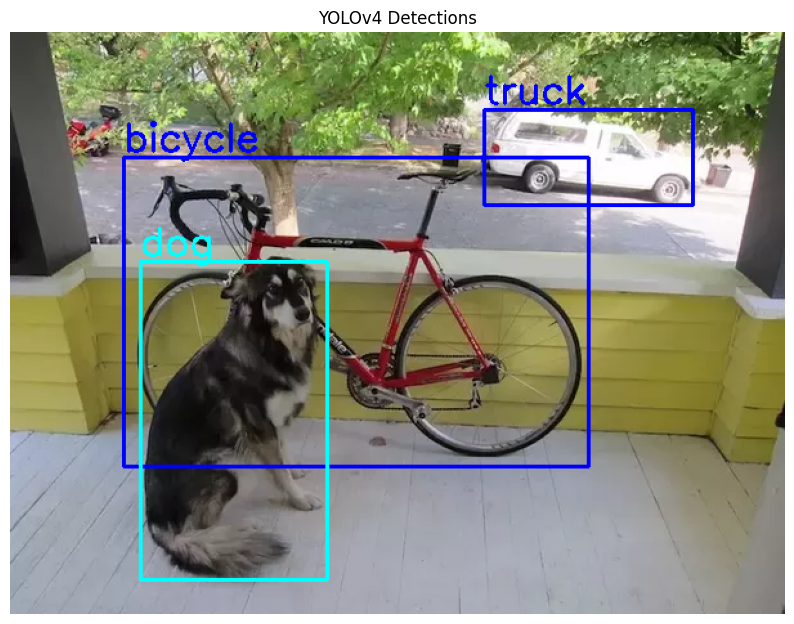

In [12]:
import matplotlib.pyplot as plt
import random
import os

# Download coco.names first
if not os.path.exists("data/coco.names"):
    os.makedirs("data", exist_ok=True)
    os.system("wget https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/data/coco.names -P data/")

# Now load class names
classes = load_classes("data/coco.names")

# Draw boxes
colors = [[255,0,0],[0,255,0],[0,0,255],[255,255,0],[0,255,255]]

# Get original image size
orig_h, orig_w = img.shape[:2]

# Scale factors
scale_x = orig_w / 608
scale_y = orig_h / 608

img_draw = img.copy()

for det in output:
    x1 = int(det[1] * scale_x)
    y1 = int(det[2] * scale_y)
    x2 = int(det[3] * scale_x)
    y2 = int(det[4] * scale_y)
    cls = int(det[7])
    label = classes[cls]
    color = random.choice(colors)
    
    cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img_draw, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

plt.figure(figsize=(10,8))
plt.imshow(img_draw)
plt.axis("off")
plt.title("YOLOv4 Detections")
plt.show()

Download COCO 

In [17]:
path2data = '/home/jupyter-st125985/fiftyone/coco-2017/validation/data/val2017'
path2json = '/home/jupyter-st125985/fiftyone/coco-2017/raw/annotations/instances_val2017.json'

img_size = 608  # YOLOv4 uses 608x608

print("Data path exists:", os.path.exists(path2data))
print("JSON path exists:", os.path.exists(path2json))

Data path exists: True
JSON path exists: True


In [18]:
# !pip install fiftyone

In [19]:
import json

# Load COCO annotations
with open(path2json) as f:
    coco_data = json.load(f)

# Save categories to coco_cats.json
cats = {"categories": coco_data["categories"]}
with open("coco_cats.json", "w") as f:
    json.dump(cats, f)

print("coco_cats.json created!")
print("Number of categories:", len(cats["categories"]))
print("First 5 categories:", cats["categories"][:5])

coco_cats.json created!
Number of categories: 80
First 5 categories: [{'supercategory': 'person', 'id': 1, 'name': 'person'}, {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'}, {'supercategory': 'vehicle', 'id': 3, 'name': 'car'}, {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'}, {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'}]


In [20]:
import os
os.system("pip install pycocotools albumentations")

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 9.4 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


0

In [21]:
import os
import sys
from PIL import Image
import torch
import math
import cv2
import numpy as np
import random
from torchvision.datasets import CocoDetection
from typing import Any, Callable, Optional, Tuple
import json
import albumentations as A

ANCHORS = [
    [[12, 16], [19, 36], [40, 28]],
    [[36, 75], [76, 55], [72, 146]],
    [[142, 110], [192, 243], [459, 401]]
]

STRIDES = [8, 16, 32]
IP_SIZE = img_size
NUM_ANCHORS = 3
NUM_CLASSES = 80

with open('coco_cats.json') as js:
    data = json.load(js)["categories"]

cats_dict = {}
for i in range(0, 80):
    cats_dict[str(data[i]['id'])] = i

print("cats_dict created! Sample:", list(cats_dict.items())[:5])

cats_dict created! Sample: [('1', 0), ('2', 1), ('3', 2), ('4', 3), ('5', 4)]


In [22]:
def iou_xywh_numpy(boxes1, boxes2):
    boxes1 = np.array(boxes1)
    boxes2 = np.array(boxes2)

    boxes1_area = boxes1[..., 2] * boxes1[..., 3]
    boxes2_area = boxes2[..., 2] * boxes2[..., 3]

    boxes1 = np.concatenate([boxes1[..., :2] - boxes1[..., 2:] * 0.5,
                              boxes1[..., :2] + boxes1[..., 2:] * 0.5], axis=-1)
    boxes2 = np.concatenate([boxes2[..., :2] - boxes2[..., 2:] * 0.5,
                              boxes2[..., :2] + boxes2[..., 2:] * 0.5], axis=-1)

    left_up = np.maximum(boxes1[..., :2], boxes2[..., :2])
    right_down = np.minimum(boxes1[..., 2:], boxes2[..., 2:])

    inter_section = np.maximum(right_down - left_up, 0.0)
    inter_area = inter_section[..., 0] * inter_section[..., 1]
    union_area = boxes1_area + boxes2_area - inter_area
    IOU = 1.0 * inter_area / union_area
    return IOU

print("iou_xywh_numpy defined!")

iou_xywh_numpy defined!


In [23]:
class CustomCoco(CocoDetection):
    def __init__(self, root, annFile, transform=None, target_transform=None, transforms=None):
        super(CocoDetection, self).__init__(root, transforms, transform, target_transform)
        from pycocotools.coco import COCO
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        target = coco.loadAnns(ann_ids)
        path = coco.loadImgs(img_id)[0]['file_name']

        img = Image.open(os.path.join(self.root, path)).convert('RGB')
        img = np.array(img)

        category_ids = list(obj['category_id'] for obj in target)
        bboxes = list(obj['bbox'] for obj in target)

        if self.transform is not None:
            transformed = self.transform(image=img, bboxes=bboxes, category_ids=category_ids)
            img = transformed['image']
            bboxes = torch.Tensor(transformed['bboxes'])
            cat_ids = torch.Tensor(transformed['category_ids'])
            labels, bboxes = self.__create_label(bboxes, cat_ids.type(torch.IntTensor))

        return img, labels, bboxes

    def __len__(self):
        return len(self.ids)

    def __create_label(self, bboxes, class_inds):
        bboxes = np.array(bboxes)
        class_inds = np.array(class_inds)
        anchors = ANCHORS
        strides = np.array(STRIDES)
        train_output_size = IP_SIZE / strides
        anchors_per_scale = NUM_ANCHORS

        label = [
            np.zeros((int(train_output_size[i]), int(train_output_size[i]), anchors_per_scale, 5 + NUM_CLASSES))
            for i in range(3)
        ]
        bboxes_xywh = [np.zeros((150, 4)) for _ in range(3)]
        bbox_count = np.zeros((3,))

        for i in range(len(bboxes)):
            bbox_coor = bboxes[i][:4]
            bbox_class_ind = cats_dict[str(class_inds[i])]

            one_hot = np.zeros(NUM_CLASSES, dtype=np.float32)
            one_hot[bbox_class_ind] = 1.0

            bbox_xywh = np.concatenate([
                (0.5 * bbox_coor[2:] + bbox_coor[:2]),
                bbox_coor[2:]
            ], axis=-1)

            bbox_xywh_scaled = 1.0 * bbox_xywh[np.newaxis, :] / strides[:, np.newaxis]

            iou = []
            exist_positive = False
            for i in range(3):
                anchors_xywh = np.zeros((anchors_per_scale, 4))
                anchors_xywh[:, 0:2] = np.floor(bbox_xywh_scaled[i, 0:2]).astype(np.int32) + 0.5
                anchors_xywh[:, 2:4] = anchors[i]

                iou_scale = iou_xywh_numpy(bbox_xywh_scaled[i][np.newaxis, :], anchors_xywh)
                iou.append(iou_scale)
                iou_mask = iou_scale > 0.3

                if np.any(iou_mask):
                    xind, yind = np.floor(bbox_xywh_scaled[i, 0:2]).astype(np.int32)
                    label[i][yind, xind, iou_mask, 0:4] = bbox_xywh * strides[i]
                    label[i][yind, xind, iou_mask, 4:5] = 1.0
                    label[i][yind, xind, iou_mask, 5:] = one_hot

                    bbox_ind = int(bbox_count[i] % 150)
                    bboxes_xywh[i][bbox_ind, :4] = bbox_xywh * strides[i]
                    bbox_count[i] += 1
                    exist_positive = True

            if not exist_positive:
                best_anchor_ind = np.argmax(np.array(iou).reshape(-1), axis=-1)
                best_detect = int(best_anchor_ind / anchors_per_scale)
                best_anchor = int(best_anchor_ind % anchors_per_scale)
                xind, yind = np.floor(bbox_xywh_scaled[best_detect, 0:2]).astype(np.int32)

                label[best_detect][yind, xind, best_anchor, 0:4] = bbox_xywh * strides[best_detect]
                label[best_detect][yind, xind, best_anchor, 4:5] = 1.0
                label[best_detect][yind, xind, best_anchor, 5:] = one_hot

                bbox_ind = int(bbox_count[best_detect] % 150)
                bboxes_xywh[best_detect][bbox_ind, :4] = bbox_xywh * strides[best_detect]
                bbox_count[best_detect] += 1

        flatten_size_s = int(train_output_size[2]) * int(train_output_size[2]) * anchors_per_scale
        flatten_size_m = int(train_output_size[1]) * int(train_output_size[1]) * anchors_per_scale
        flatten_size_l = int(train_output_size[0]) * int(train_output_size[0]) * anchors_per_scale

        label_s = torch.Tensor(label[2]).view(1, flatten_size_s, 5 + NUM_CLASSES).squeeze(0)
        label_m = torch.Tensor(label[1]).view(1, flatten_size_m, 5 + NUM_CLASSES).squeeze(0)
        label_l = torch.Tensor(label[0]).view(1, flatten_size_l, 5 + NUM_CLASSES).squeeze(0)

        labels = torch.cat([label_l, label_m, label_s], 0)
        bboxes = torch.cat([torch.Tensor(bboxes_xywh[0]), torch.Tensor(bboxes_xywh[1]), torch.Tensor(bboxes_xywh[2])], 0)
        return labels, bboxes

print("CustomCoco class defined!")

CustomCoco class defined!


In [24]:
import torch
from torch.utils.data import Subset

BATCH_SIZE = 8

train_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

def collate_fn(batch):
    return tuple(zip(*batch))

# Use only 500 images for faster training
train_dataset = Subset(
    CustomCoco(root=path2data, annFile=path2json, transform=train_transform),
    list(range(0, 500))
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn
)

print("Dataloader created!")
print("Total batches:", len(train_dataloader))

loading annotations into memory...
Done (t=0.60s)
creating index...
index created!
Dataloader created!
Total batches: 63


In [25]:
def CIOU_xywh_torch(boxes1, boxes2):
    boxes1 = torch.cat([boxes1[..., :2] - boxes1[..., 2:] * 0.5,
                        boxes1[..., :2] + boxes1[..., 2:] * 0.5], dim=-1)
    boxes2 = torch.cat([boxes2[..., :2] - boxes2[..., 2:] * 0.5,
                        boxes2[..., :2] + boxes2[..., 2:] * 0.5], dim=-1)

    boxes1_area = (boxes1[..., 2] - boxes1[..., 0]) * (boxes1[..., 3] - boxes1[..., 1])
    boxes2_area = (boxes2[..., 2] - boxes2[..., 0]) * (boxes2[..., 3] - boxes2[..., 1])

    inter_left_up = torch.max(boxes1[..., :2], boxes2[..., :2])
    inter_right_down = torch.min(boxes1[..., 2:], boxes2[..., 2:])
    inter_section = torch.max(inter_right_down - inter_left_up, torch.zeros_like(inter_right_down))
    inter_area = inter_section[..., 0] * inter_section[..., 1]
    union_area = boxes1_area + boxes2_area - inter_area
    ious = 1.0 * inter_area / (union_area + 1e-6)

    outer_left_up = torch.min(boxes1[..., :2], boxes2[..., :2])
    outer_right_down = torch.max(boxes1[..., 2:], boxes2[..., 2:])
    outer = torch.max(outer_right_down - outer_left_up, torch.zeros_like(inter_right_down))
    outer_diagonal_line = torch.pow(outer[..., 0], 2) + torch.pow(outer[..., 1], 2)

    boxes1_center = (boxes1[..., :2] + boxes1[..., 2:]) * 0.5
    boxes2_center = (boxes2[..., :2] + boxes2[..., 2:]) * 0.5
    center_dis = torch.pow(boxes1_center[..., 0] - boxes2_center[..., 0], 2) + \
                 torch.pow(boxes1_center[..., 1] - boxes2_center[..., 1], 2)

    boxes1_size = torch.max(boxes1[..., 2:] - boxes1[..., :2], torch.zeros_like(inter_right_down))
    boxes2_size = torch.max(boxes2[..., 2:] - boxes2[..., :2], torch.zeros_like(inter_right_down))
    v = (4 / (math.pi ** 2)) * torch.pow(
        torch.atan(boxes1_size[..., 0] / torch.clamp(boxes1_size[..., 1], min=1e-6)) -
        torch.atan(boxes2_size[..., 0] / torch.clamp(boxes2_size[..., 1], min=1e-6)), 2)

    alpha = v / (1 - ious + v + 1e-6)
    cious = ious - (center_dis / (outer_diagonal_line + 1e-6) + alpha * v)
    return cious

print("CIOU_xywh_torch defined!")

CIOU_xywh_torch defined!


In [26]:
def train_yolo(model, optimizer, dataloader, device, img_size, n_epoch, use_ciou=False):
    model.train()
    loss_history = []
    
    for epoch in range(n_epoch):
        running_loss = 0.0
        for inputs, labels, bboxes in dataloader:
            inputs = torch.from_numpy(np.array(inputs)).squeeze(1).permute(0,3,1,2).float()
            inputs = inputs.to(device)
            labels = torch.stack(labels).to(device)

            optimizer.zero_grad()
            
            with torch.set_grad_enabled(True):
                outputs = model(inputs, torch.cuda.is_available())

                pred_xywh = outputs[..., 0:4] / img_size
                pred_conf = outputs[..., 4:5]
                pred_cls  = outputs[..., 5:]

                label_xywh     = labels[..., :4] / img_size
                label_obj_mask = labels[..., 4:5]
                label_noobj    = 1.0 - label_obj_mask
                label_cls      = labels[..., 5:]

                bce = nn.BCELoss(reduction='none')

                if use_ciou:
                    # CIoU loss
                    ciou = CIOU_xywh_torch(pred_xywh, label_xywh).unsqueeze(-1)
                    loss_box = torch.sum(label_obj_mask * (1.0 - ciou))
                else:
                    # MSE loss
                    mse = nn.MSELoss(reduction='none')
                    loss_box = torch.sum(label_obj_mask * mse(pred_xywh, label_xywh))

                loss_conf = torch.sum(
                    label_obj_mask * bce(pred_conf, label_obj_mask) +
                    0.05 * label_noobj * bce(pred_conf, label_obj_mask)
                )
                loss_cls = torch.sum(label_obj_mask * bce(pred_cls, label_cls))

                loss = loss_box + loss_conf + loss_cls
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

        epoch_loss = running_loss / len(dataloader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1}/{n_epoch}  Loss: {epoch_loss:.4f}")
    
    return loss_history

print("train_yolo() defined!")

train_yolo() defined!


In [32]:
# Clear memory
torch.cuda.empty_cache()
import gc
gc.collect()

# Single GPU
device = torch.device("cuda:0")

# Use 416 to fit in memory
img_size = 416

# Reload model
model = darknet.Darknet("cfg/yolov4.cfg")
model.load_weights("yolov4.weights")
model.net_info["height"] = str(img_size)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Recreate dataloader
BATCH_SIZE = 4
train_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

train_dataset = Subset(
    CustomCoco(root=path2data, annFile=path2json, transform=train_transform),
    list(range(0, 500))
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn
)

print("Ready!")
print("Device:", device)
print("Batch size:", BATCH_SIZE)
print("Total batches:", len(train_dataloader))

RuntimeError: CUDA error: misaligned address
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
